In [10]:
from transformers import ConvNextForImageClassification, ConvNextImageProcessor
from PIL import Image
import torch

CHECKPOINT_PATH = "Models/convnext_crop/checkpoint-7035"

inference_model = ConvNextForImageClassification.from_pretrained(CHECKPOINT_PATH)
inference_processor = ConvNextImageProcessor.from_pretrained(CHECKPOINT_PATH)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
inference_model = inference_model.to(device)
inference_model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"Using device: {device}")

Model loaded from Models/convnext_crop/checkpoint-7035
Using device: mps


In [11]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, target_class=None):
        output = self.model(**input_tensor)
        
        if target_class is None:
            target_class = output.logits.argmax(dim=1).item()
        
        self.model.zero_grad()
        output.logits[0, target_class].backward(retain_graph=True)
        

        gradients = self.gradients.cpu().numpy()[0]
        activations = self.activations.cpu().numpy()[0]
        
        weighted_activations = gradients * activations
        
        cam = np.sum(weighted_activations, axis=0)
        
        cam = np.maximum(cam, 0)
        
        if np.max(cam) > 0:
            cam = cam / np.max(cam)
            
        return cam, target_class

In [14]:
from scipy.ndimage import gaussian_filter 

def visualize_gradcam(image_path, model, processor, device, gradcam, figsize=(15, 5), sigma=1.0):

    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    model.eval()
    cam, predicted_class = gradcam.generate_cam(inputs)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
        confidence = probabilities[0, predicted_class].item()
    
    label = model.config.id2label[predicted_class]

    smoothed_cam = gaussian_filter(cam, sigma=sigma)


    cam_resized = cv2.resize(smoothed_cam, (image.width, image.height), interpolation=cv2.INTER_CUBIC)
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    axes[0].imshow(image)
    axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    

    im = axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap", fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    axes[2].imshow(image)
    axes[2].imshow(cam_resized, cmap='jet', alpha=0.5) 
    axes[2].set_title("Overlay", fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    fig.suptitle(f"Prediction: {label}\nConfidence: {confidence*100:.2f}%", 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    return cam_resized, label, confidence



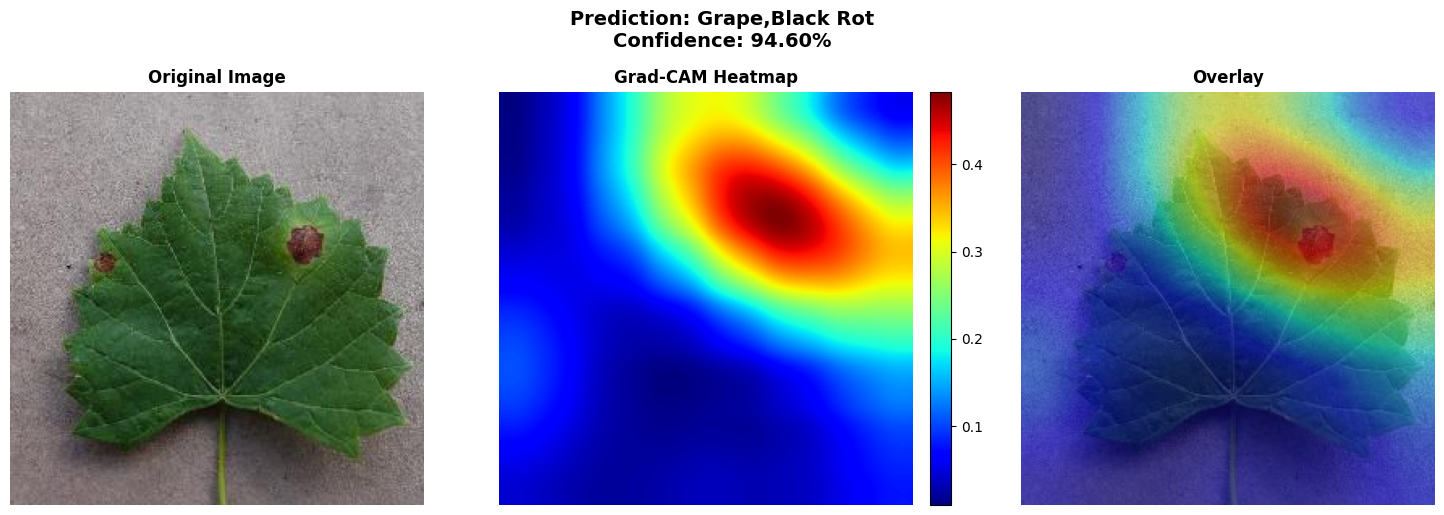

(array([[0.01261804, 0.01227384, 0.01198289, ..., 0.05952706, 0.05984627,
         0.06022391],
        [0.01259135, 0.01224706, 0.01195604, ..., 0.05890173, 0.05922036,
         0.05959729],
        [0.01256879, 0.01222443, 0.01193335, ..., 0.05837316, 0.05869129,
         0.05906764],
        ...,
        [0.04423188, 0.04431143, 0.04437868, ..., 0.07830082, 0.07818584,
         0.07804981],
        [0.04438266, 0.0444626 , 0.04453018, ..., 0.07842351, 0.07830833,
         0.07817204],
        [0.04456104, 0.04464144, 0.04470941, ..., 0.07856867, 0.07845323,
         0.07831664]], shape=(256, 256), dtype=float32),
 'Grape,Black Rot',
 0.9459854364395142)

In [17]:
target_layer = inference_model.convnext.encoder.stages[-1].layers[-1]

image_path="dataset/images/Grape,Black Rot/plant_114646.jpg"

gradcam = GradCAM(inference_model, target_layer)

visualize_gradcam(
    image_path=image_path,
    model=inference_model,
    processor=inference_processor,
    gradcam=gradcam,
    device=device
)